In [1]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import os

In [2]:
file = '~/Desktop/Dont Know/customer_segmentation/dataset/Mall_Customers.csv'
df=pd.read_csv(file)

In [3]:
display(df.head())
display(df.tail())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df=df.rename(columns={'Annual Income (k$)':'Annual Income' 	,'Spending Score (1-100)':'Spending Score'})

In [8]:
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df=df.drop(columns=['Gender', 'CustomerID', 'Age'])

In [10]:
df.head()

,Annual Income,Spending Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [11]:
scaler=sk.preprocessing.StandardScaler()
df=scaler.fit_transform(df)

In [12]:
elbow=[]

for k in range(1,10):
    kmeans=sk.cluster.KMeans(n_clusters=k, random_state=77, n_init=10)
    kmeans.fit(df)
    elbow.append(kmeans.inertia_)

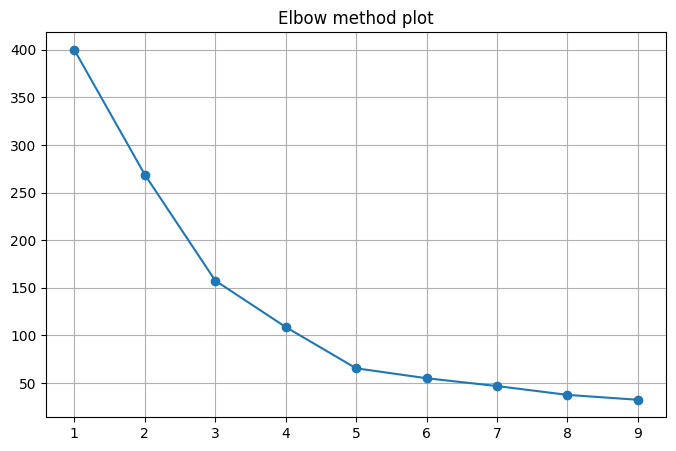

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1,10), elbow, marker='o')
plt.title('Elbow method plot')
plt.grid(True)
plt.savefig(os.path.expanduser('~/Desktop/Dont Know/customer_segmentation/screenshots/elbow_plot.png'))

In [14]:
for k in range(2,9):
    kmeans=sk.cluster.KMeans(n_clusters=k, random_state=77, n_init=10)
    pred=kmeans.fit_predict(df)
    score=sk.metrics.silhouette_score(df,pred)
    print(f'for k={k} silhouette score is {score}')

for k=2 silhouette score is 0.29512063001659344
for k=3 silhouette score is 0.46658474419000145
for k=4 silhouette score is 0.4939069237513199
for k=5 silhouette score is 0.5546571631111091
for k=6 silhouette score is 0.5380630705007142
for k=7 silhouette score is 0.45181441290087215
for k=8 silhouette score is 0.45508447962411985


In [15]:
kmeans=sk.cluster.KMeans(n_clusters=5, random_state=77, n_init=10)
labels=kmeans.fit_predict(df)

In [16]:
centers=kmeans.cluster_centers_
X=df

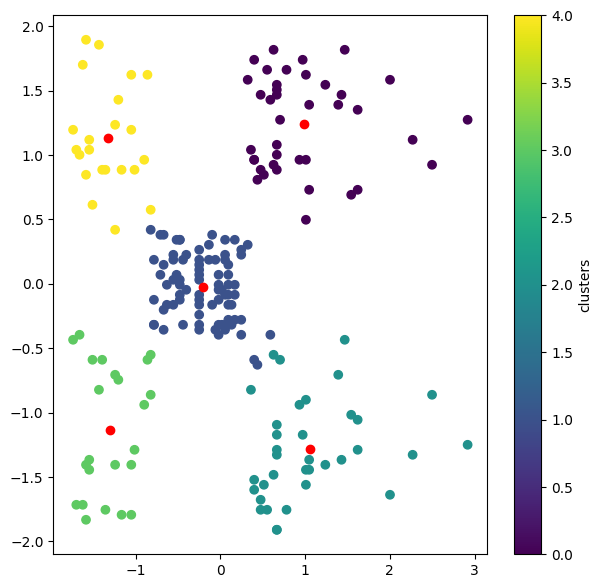

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.colorbar(label='clusters')
plt.scatter(centers[:,0], centers[:,1], c='red', label='Centroids')
plt.savefig(os.path.expanduser('~/Desktop/Dont Know/customer_segmentation/screenshots/segmentation_plot.png'))

In [18]:
print(centers)

[[ 0.99158305  1.23950275]
 [-0.20091257 -0.02645617]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]
 [-1.32954532  1.13217788]]


In [19]:
segment_map={0:'premium customer', 1:'average customer', 2:'wealthy, conservative spender', 3:'low-value customer', 4:'impulsive spender'}

In [20]:
df=pd.DataFrame(df)
df['cluster']=kmeans.labels_
df['segment']=df['cluster'].map(segment_map)

In [21]:
df.head()

,0,1,cluster,segment
0,-1.738999,-0.434801,3,low-value customer
1,-1.738999,1.195704,4,impulsive spender
2,-1.700830,-1.715913,3,low-value customer
3,-1.700830,1.040418,4,impulsive spender
4,-1.662660,-0.395980,3,low-value customer


In [22]:
df.to_csv('~/Desktop/Dont Know/customer_segmentation/dataset/Mall_Customers_Processed.csv')

In [23]:
import joblib as jb
jb.dump(kmeans, os.path.expanduser('~/Desktop/Dont Know/customer_segmentation/model/kmeans.joblib' ))
jb.dump(scaler, os.path.expanduser('~/Desktop/Dont Know/customer_segmentation/model/std_scaler.joblib' ))

['C:\\Users\\Thirtesh/Desktop/Dont Know/customer_segmentation/model/std_scaler.joblib']

In [31]:
income=int(input('Enter the annual income(k$):'))
spend_score=int(input('Enter the spending score(1-100):'))
print(segment_map[kmeans.predict(scaler.transform([[income,spend_score]]))[0]])

Enter the annual income(k$): 25
Enter the spending score(1-100): 90


impulsive spender


C:\Users\Thirtesh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
